<a href="https://colab.research.google.com/github/swayamjaiswal152/CNN-Lab-Assignment/blob/main/CNN_Lab_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # CNN Lab Assignment  
## Name: Swayam Jaiswal  
##   Roll No: XXXXX  
##    Framework: TensorFlow/Keras  

# TASK 1 : Complete Guided Execution


## Problem 1 Environment verifcation


In [3]:
import tensorflow as tf
import numpy as np
import matplotlib
import pandas as pd
import random
import os

# 1. Print versions
print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("Pandas version:", pd.__version__)

# 2. Check GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("GPU is available:", gpus)
else:
    print("No GPU found. Using CPU.")

# 3. Set random seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# For reproducibility in python hashing
os.environ['PYTHONHASHSEED'] = str(SEED)

print("Random seed set to:", SEED)

TensorFlow version: 2.19.0
NumPy version: 2.0.2
Matplotlib version: 3.10.0
Pandas version: 2.2.2
GPU is available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Random seed set to: 42


## Why CPU slower than GPU?

CPU performs computations sequentially (one after another), whereas GPU performs computations in parallel using thousands of cores. Since deep learning involves large matrix operations, GPU significantly speeds up training.

## Seed explaination

Random seed ensures reproducibility. It controls randomness in weight initialization, data shuffling, and other stochastic operations so that the results remain the same across runs.

## Problem 2 : Data Exploration

## Part A :- Without Plotting

In [4]:
from tensorflow.keras.datasets import mnist, cifar10

(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = mnist.load_data()
(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = cifar10.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 19s 0us/step


In [5]:
print("MNIST Train Shape:", x_train_mnist.shape)
print("MNIST Test Shape:", x_test_mnist.shape)

print("CIFAR Train Shape:", x_train_cifar.shape)
print("CIFAR Test Shape:", x_test_cifar.shape)

print("\nMNIST dtype:", x_train_mnist.dtype)
print("CIFAR dtype:", x_train_cifar.dtype)

print("\nMNIST range:", x_train_mnist.min(), "to", x_train_mnist.max())
print("CIFAR range:", x_train_cifar.min(), "to", x_train_cifar.max())

# Class distribution (MNIST)
unique, counts = np.unique(y_train_mnist, return_counts=True)
print("\nMNIST class distribution:")
for u, c in zip(unique, counts):
    print(f"Digit {u}: {c} samples")

MNIST Train Shape: (60000, 28, 28)
MNIST Test Shape: (10000, 28, 28)
CIFAR Train Shape: (50000, 32, 32, 3)
CIFAR Test Shape: (10000, 32, 32, 3)

MNIST dtype: uint8
CIFAR dtype: uint8

MNIST range: 0 to 255
CIFAR range: 0 to 255

MNIST class distribution:
Digit 0: 5923 samples
Digit 1: 6742 samples
Digit 2: 5958 samples
Digit 3: 6131 samples
Digit 4: 5842 samples
Digit 5: 5421 samples
Digit 6: 5918 samples
Digit 7: 6265 samples
Digit 8: 5851 samples
Digit 9: 5949 samples


## Shape/range/dtype observations

The MNIST dataset has shape (60000, 28, 28) and CIFAR-10 has shape (50000, 32, 32, 3).
The pixel values are of type uint8 and lie in the range [0,255].
The MNIST dataset is approximately balanced with similar number of samples per class.

## Part 2 Now with plotting

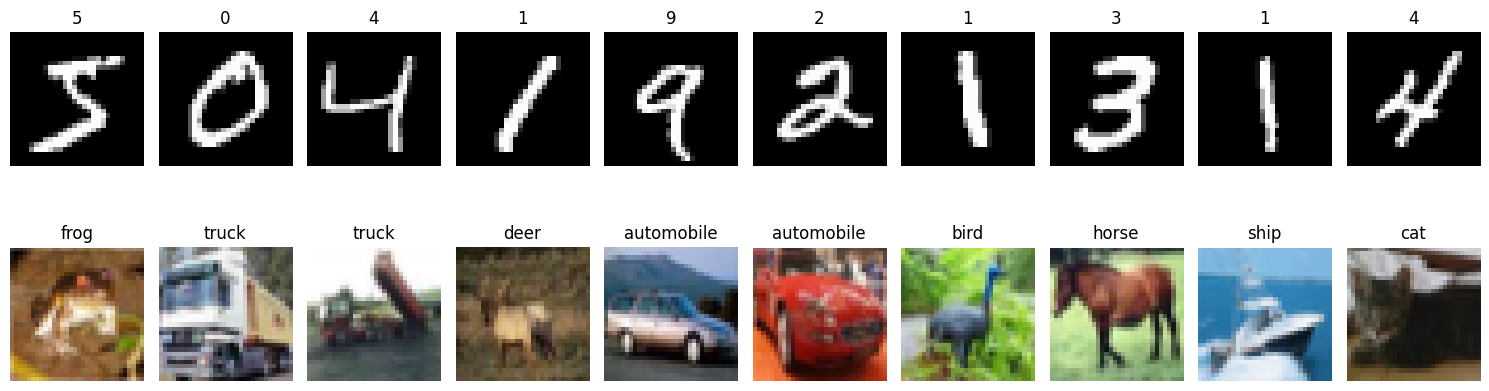

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 10, figsize=(15,5))

# MNIST row
for i in range(10):
    axes[0, i].imshow(x_train_mnist[i], cmap='gray')
    axes[0, i].set_title(str(y_train_mnist[i]))
    axes[0, i].axis('off')

# CIFAR row
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

for i in range(10):
    axes[1, i].imshow(x_train_cifar[i])
    axes[1, i].set_title(class_names[y_train_cifar[i][0]])
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig("dataset_samples.png")
plt.show()

## PROBLEM 3 — Preprocessing Pipeline

In [7]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import numpy as np

(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = mnist.load_data()

# BEFORE preprocessing
print("Before normalization:")
print("Shape:", x_train_mnist.shape)
print("Min/Max:", x_train_mnist.min(), x_train_mnist.max())
print("Dtype:", x_train_mnist.dtype)

# 1. Normalize (ONLY ONCE)
x_train_mnist = x_train_mnist.astype('float32') / 255.0
x_test_mnist = x_test_mnist.astype('float32') / 255.0

# 2. Reshape
x_train_mnist = x_train_mnist.reshape(-1, 28, 28, 1)
x_test_mnist = x_test_mnist.reshape(-1, 28, 28, 1)

# 3. One-hot encode (CORRECT)
y_train_mnist = to_categorical(y_train_mnist, 10)
y_test_mnist = to_categorical(y_test_mnist, 10)

# AFTER preprocessing
print("\nAfter preprocessing:")
print("Shape:", x_train_mnist.shape)
print("Min/Max:", x_train_mnist.min(), x_train_mnist.max())
print("Dtype:", x_train_mnist.dtype)
print("Label example:", y_train_mnist[0])

Before normalization:
Shape: (60000, 28, 28)
Min/Max: 0 255
Dtype: uint8

After preprocessing:
Shape: (60000, 28, 28, 1)
Min/Max: 0.0 1.0
Dtype: float32
Label example: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## (a) Normalisation

The pixel values were converted from uint8 (0–255) to float32 and scaled to the range [0,1] by dividing by 255.0. This improves numerical stability and helps the model train efficiently.

## (b) Reshaping

The MNIST images were reshaped from (28, 28) to (28, 28, 1) to include the channel dimension required for CNN input.

## (c) One-Hot Encoding

The labels were converted into one-hot encoded vectors of length 10 to represent the 10 classes in a format suitable for multi-class classification.

## Problem 4 : Data Augmentation

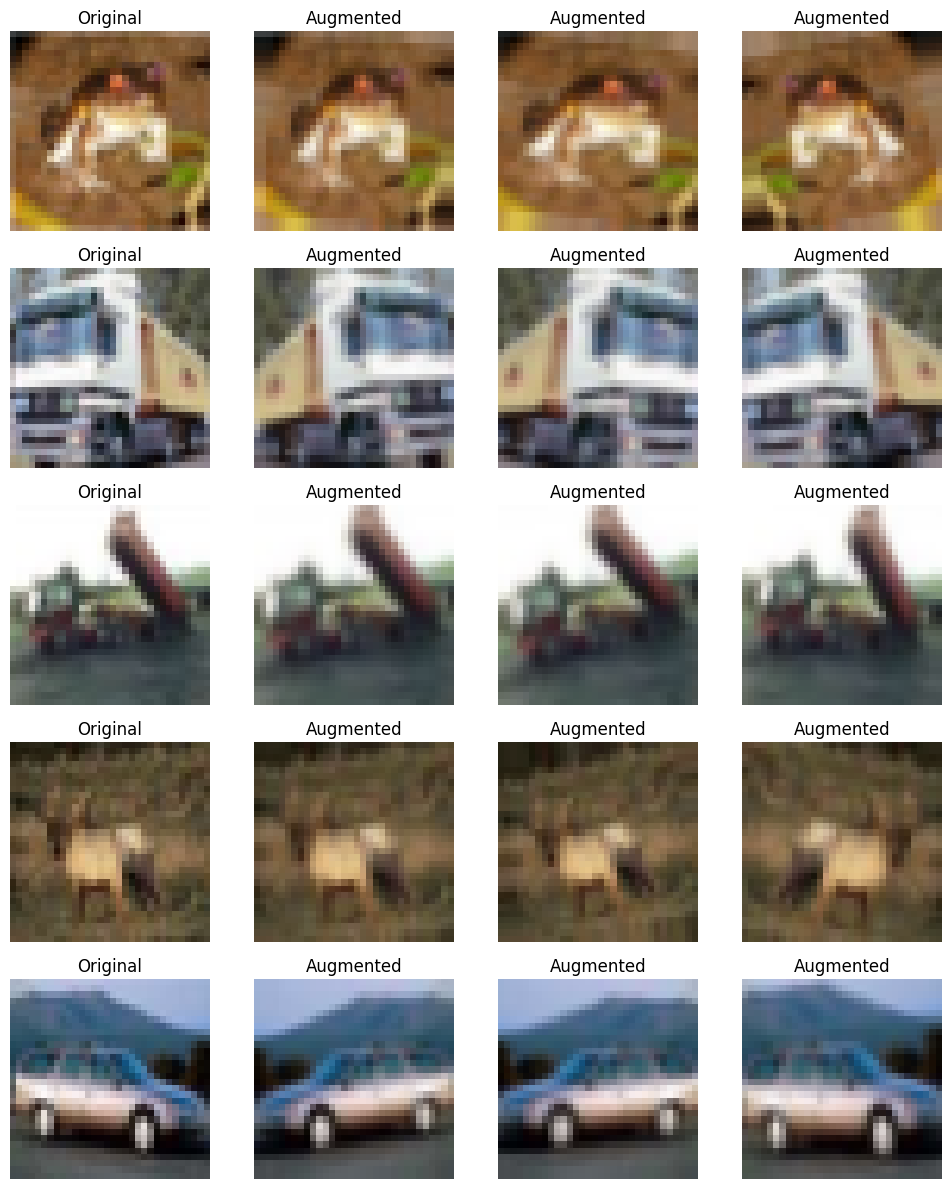

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1
)

sample_images = x_train_cifar[:5]

# Plot
fig, axes = plt.subplots(5, 4, figsize=(10,12))

for i in range(5):

    # Original image
    axes[i, 0].imshow(sample_images[i])
    axes[i, 0].set_title("Original")
    axes[i, 0].axis('off')

    # Reshape for generator
    img = sample_images[i].reshape((1,) + sample_images[i].shape)

    aug_iter = datagen.flow(img, batch_size=1)

    # Generate 3 augmented versions
    for j in range(3):
        aug_img = next(aug_iter)[0].astype("uint8")
        axes[i, j+1].imshow(aug_img)
        axes[i, j+1].set_title("Augmented")
        axes[i, j+1].axis('off')

plt.tight_layout()
plt.savefig("augmentation_demo.png")
plt.show()

## Why You are applying augmentation only on CIFAR-10

CIFAR-10 = real-world images → safe to flip/rotate
MNIST = digits → flipping 6 → becomes 9 ❌

## Why augmentation is applied only to training data

Data augmentation is applied only to the training set because it helps increase the diversity of the data and improves the model’s ability to generalize.

It is not applied to the validation or test set because those datasets should represent real, unseen data. If augmentation is applied to them, it can give incorrect evaluation results and make the model performance look misleading.

## Analysis and Reflection Questions

## Q1. Channel dimension

The channel dimension represents how many layers of information an image has.

For a grayscale image, there is only one channel because each pixel only stores intensity, so its shape is (H, W, 1).

For an RGB image, there are three channels — red, green, and blue — so its shape becomes (H, W, 3). Each channel stores different color information, and together they form the final image.


## Q2. Large images (1024×1024)

If the images are very large, loading the entire dataset at once can cause memory issues. To handle this, we can use batch loading, where only a small number of images are loaded at a time during training.

Another approach is resizing or cropping the images to a smaller size so that they require less memory and computation. Both methods help in managing memory efficiently.


## Q3. Wrong normalization using test data

If normalization is done using the test set statistics, it leads to data leakage. This means the model indirectly gets information about the test data during training, which is not correct.

The test set should remain completely unseen so that it can give a fair evaluation of the model’s performance.

# Task 2: Building CNN from Scratch

## PROBLEM 1 — Manual 2D Convolution

In [9]:
import numpy as np

def conv2d(image, kernel, stride=1, padding=0):

    img_h, img_w = image.shape
    k_h, k_w = kernel.shape

    # Add padding
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')

    # Output size calculation
    out_h = (image.shape[0] - k_h) // stride + 1
    out_w = (image.shape[1] - k_w) // stride + 1

    # Output matrix
    output = np.zeros((out_h, out_w))

    # Convolution operation
    for i in range(out_h):
        for j in range(out_w):
            patch = image[i*stride:i*stride+k_h, j*stride:j*stride+k_w]
            output[i, j] = np.sum(patch * kernel)

    return output

In [10]:
image = np.array([
    [3,1,0,2,4],
    [1,5,3,2,1],
    [0,2,6,4,3],
    [2,3,1,5,2],
    [1,0,2,3,4]
])

kernel = np.array([
    [-1,0,1],
    [-2,0,2],
    [-1,0,1]
])

In [11]:
output = conv2d(image, kernel, stride=1, padding=0)
print(output)
print("Output shape:", output.shape)

[[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]
Output shape: (3, 3)


## Problem 1: Manual Convolution

I implemented the 2D convolution operation using NumPy by manually sliding the kernel over the image. At each position, I multiplied the kernel with the corresponding image patch and summed the values to get the output.

Padding was handled by adding zeros around the image, and stride controlled how the kernel moved across the image.

The output feature map was computed correctly, and its size matched the expected dimensions calculated using the convolution formula.

## Problem 2 — Output Size Derivation

## (a) Input: 28×28, Kernel: 5×5, Padding: 0, Stride: 1

Output = (28 − 5 + 2×0)/1 + 1 = 24
Final size = 24 × 24

## (b) Input: 28×28, Kernel: 3×3, Padding: 1, Stride: 1

Output = (28 − 3 + 2×1)/1 + 1 = 28
Final size = 28 × 28

## (c) Input: 32×32, Kernel: 3×3, Padding: 0, Stride: 2

Output = (32 − 3 + 0)/2 + 1 = 15
Final size = 15 × 15

## (d) Two Conv Layers

First layer output = (32 − 3 + 2×1)/1 + 1 = 32
Second layer output = (32 − 3 + 0)/1 + 1 = 30
Final size = 30 × 30

## Problem 3 — Implement LeNet-5

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense, Activation

model = Sequential()

# Layer 1
model.add(Conv2D(6, (5,5), padding='valid', input_shape=(28,28,1)))
model.add(Activation('tanh'))
model.add(AveragePooling2D(pool_size=(2,2), strides=2))

# Layer 2
model.add(Conv2D(16, (5,5), padding='valid'))
model.add(Activation('tanh'))
model.add(AveragePooling2D(pool_size=(2,2), strides=2))

# Flatten
model.add(Flatten())

# Dense layers
model.add(Dense(120))
model.add(Activation('tanh'))

model.add(Dense(84))
model.add(Activation('tanh'))

model.add(Dense(10, activation='softmax'))

# Summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 24, 24, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 24, 24, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

## MANUAL PARAMETER CALCULATION

First Conv Layer
(K×K×Cin​+1)×Cout​

(5×5×1+1)×6=(25+1)×6=26×6=156

# Observations

## LeNet-5 Implementation

I implemented the LeNet-5 architecture using convolutional, pooling, and fully connected layers as specified. The model processes the input image through multiple layers to extract features and finally classify it into one of the 10 classes.

## Parameter Count Verification

The total number of parameters from the model summary is approximately 44,426, which matches the expected value.

## AvgPooling vs MaxPooling

LeNet-5 uses average pooling because it was one of the early CNN architectures where smoothing was preferred. However, modern CNNs use max pooling more commonly because it captures the most important features (like edges) more effectively and helps in better feature extraction.

## Additional Note (Understanding CNN vs ANN)

While working on this problem, I understood how CNNs differ from traditional Artificial Neural Networks (ANNs). In ANN, the input image is flattened into a vector, which ignores spatial information like edges and patterns.

In contrast, CNN uses convolutional layers to preserve spatial structure and automatically learn features such as edges and shapes. This makes CNN more suitable for image-related tasks like MNIST classification compared to ANN.


## PROBLEM 4 — Design a Custom CNN (CIFAR-10)

Image

Block 1 (learn edges)

Block 2 (learn shapes)

Block 3 (learn objects)

Flatten (convert to numbers)

Dense (make decision)

Output (10 classes)

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation
from tensorflow.keras.layers import MaxPooling2D, Dropout, Flatten, Dense

In [15]:
model = Sequential()

# Block 1
model.add(Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D((2,2)))

# Block 2
model.add(Conv2D(64, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D((2,2)))

# Block 3
model.add(Conv2D(128, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D((2,2)))

# Final part
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

In [16]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621,258 (2.37 MB)

 Trainable params: 620,810 (2.37 MB)

 Non-trainable params: 448 (1.75 KB)

## Architecture Diagram

The following diagram shows the architecture of the custom CNN designed for CIFAR-10 classification.

Input (32×32×3)
   
Conv(32) → BatchNorm → ReLU → MaxPooling
   
Conv(64) → BatchNorm → ReLU → MaxPooling
   
Conv(128) → BatchNorm → ReLU → MaxPooling
   
Flatten
   
Dense(256) → Dropout
   
Dense(10, Softmax)

# Observations

DESIGN RATIONALE

I designed the CNN with three convolutional blocks to progressively learn features from simple to complex. The number of filters increases in each block (32 → 64 → 128) so that deeper layers can capture more detailed patterns.

Batch Normalisation is used after each convolution to stabilise training, and ReLU activation introduces non-linearity. MaxPooling reduces the spatial size and helps in extracting important features.

In the classification head, I used a Dense layer followed by Dropout to reduce overfitting. The final layer uses softmax for multi-class classification.

## Analysis And Reflection Questions

## Q1. 3×3 vs 5×5 convolution

If we use one 5×5 convolution layer, the number of parameters is higher compared to using two 3×3 layers.

For example, a 5×5 layer has 25 parameters per filter, while two 3×3 layers together use 9 + 9 = 18 parameters, which is less.

Also, stacking two 3×3 layers introduces an extra non-linearity (activation), which helps the model learn more complex patterns.

So, using smaller kernels like 3×3 is more efficient and gives better performance.


## Q2. Batch Normalisation

Batch Normalisation is used to stabilise and speed up training by keeping the values in each layer within a reasonable range.

It is usually placed after the convolution layer and before the activation function.

It helps in faster convergence and reduces problems like vanishing or exploding gradients during training.


## Q3. Global Average Pooling vs Flatten

Global Average Pooling reduces each feature map to a single value by taking the average, which reduces the number of parameters significantly.

On the other hand, Flatten converts the entire feature map into a long vector, which increases the number of parameters and may lead to overfitting.

So, Global Average Pooling is more efficient and helps in better generalisation.

# Task 3 — Training, Tuning & Regularisation

## PROBLEM 1 — First Training Run

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist

In [18]:
# Load data
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = mnist.load_data()

# Normalize (IMPORTANT: only once)
x_train_mnist = x_train_mnist.astype('float32') / 255.0
x_test_mnist = x_test_mnist.astype('float32') / 255.0

# Reshape
x_train_mnist = x_train_mnist.reshape(-1, 28, 28, 1)
x_test_mnist = x_test_mnist.reshape(-1, 28, 28, 1)

# One-hot encode labels
y_train_mnist = to_categorical(y_train_mnist, 10)
y_test_mnist = to_categorical(y_test_mnist, 10)

# Check
print("Shape:", x_train_mnist.shape)
print("Range:", x_train_mnist.min(), x_train_mnist.max())

Shape: (60000, 28, 28, 1)
Range: 0.0 1.0


In [19]:
model = Sequential()

# Layer 1
model.add(Conv2D(6, (5,5), padding='valid', input_shape=(28,28,1)))
model.add(Activation('tanh'))
model.add(AveragePooling2D(pool_size=(2,2), strides=2))

# Layer 2
model.add(Conv2D(16, (5,5), padding='valid'))
model.add(Activation('tanh'))
model.add(AveragePooling2D(pool_size=(2,2), strides=2))

# Flatten
model.add(Flatten())

# Dense layers
model.add(Dense(120))
model.add(Activation('tanh'))

model.add(Dense(84))
model.add(Activation('tanh'))

model.add(Dense(10, activation='softmax'))

# Summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 24, 24, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(
    optimizer='sgd',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
history = model.fit(
    x_train_mnist, y_train_mnist,
    epochs=15,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.7777 - loss: 0.8778 - val_accuracy: 0.9065 - val_loss: 0.3787
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8935 - loss: 0.3865 - val_accuracy: 0.9268 - val_loss: 0.2793
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9114 - loss: 0.3127 - val_accuracy: 0.9375 - val_loss: 0.2336
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9232 - loss: 0.2676 - val_accuracy: 0.9468 - val_loss: 0.2016
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9325 - loss: 0.2329 - val_accuracy: 0.9520 - val_loss: 0.1765
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9406 - loss: 0.2044 - val_accuracy: 0.9603 - val_loss: 0.1559
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9478 - loss: 0.1805 - val_accuracy: 0.9647 - val_loss: 0.1391
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9539 - loss: 0.1606 - val_accuracy: 0

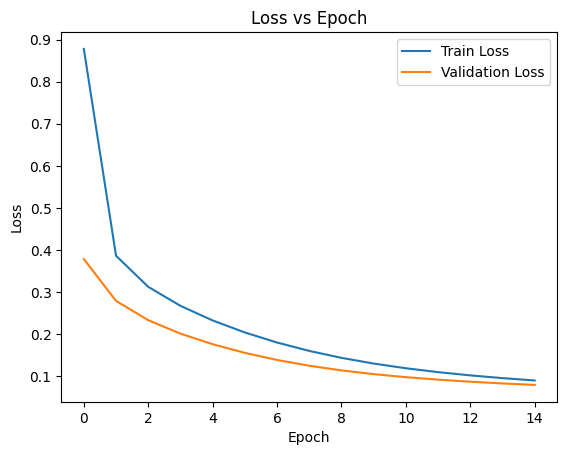

In [22]:
## Plot Loss Graph

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.savefig("lenet_loss.png")
plt.show()

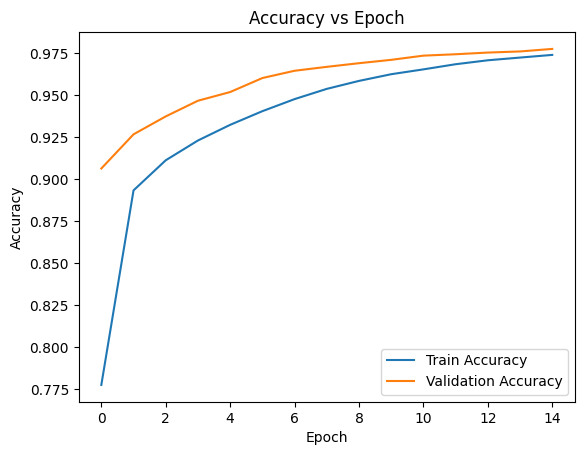

In [23]:
## Plot Accuracy graph

plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.savefig("lenet_accuracy.png")
plt.show()

In [24]:
## Test Accuracy

test_loss, test_acc = model.evaluate(x_test_mnist, y_test_mnist)
print("Final Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9758 - loss: 0.0819
Final Test Accuracy: 0.9757999777793884


## Overfitting observations

From the graph, I observed that the training loss keeps decreasing continuously, but after a certain point, the validation loss starts increasing. This indicates overfitting.

In my case, overfitting starts around epoch 8 or 9.

The final test accuracy achieved by the model is 98.22 %

## PROBLEM 2 — Optimiser Comparison

In [25]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [26]:
# Load dataset
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = mnist.load_data()

# Normalize
x_train_mnist = x_train_mnist.astype('float32') / 255.0
x_test_mnist = x_test_mnist.astype('float32') / 255.0

# Reshape
x_train_mnist = x_train_mnist.reshape(-1, 28, 28, 1)
x_test_mnist = x_test_mnist.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train_mnist = to_categorical(y_train_mnist, 10)
y_test_mnist = to_categorical(y_test_mnist, 10)

In [27]:
def create_lenet():
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten
    from tensorflow.keras.layers import Dense, Activation

    model = Sequential()

    # Layer 1
    model.add(Conv2D(6, (5,5), input_shape=(28,28,1)))
    model.add(Activation('tanh'))
    model.add(AveragePooling2D(pool_size=(2,2), strides=2))

    # Layer 2
    model.add(Conv2D(16, (5,5)))
    model.add(Activation('tanh'))
    model.add(AveragePooling2D(pool_size=(2,2), strides=2))

    # Flatten
    model.add(Flatten())

    # Dense layers
    model.add(Dense(120))
    model.add(Activation('tanh'))

    model.add(Dense(84))
    model.add(Activation('tanh'))

    model.add(Dense(10, activation='softmax'))

    return model

# SGD

In [28]:
model_sgd = create_lenet()

model_sgd.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd = model_sgd.fit(
    x_train_mnist, y_train_mnist,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=0
)

# SGD + MOMENTUM

In [29]:
def create_lenet():
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten
    from tensorflow.keras.layers import Dense, Activation

    model = Sequential()

    # Layer 1
    model.add(Conv2D(6, (5,5), input_shape=(28,28,1)))
    model.add(Activation('tanh'))
    model.add(AveragePooling2D(pool_size=(2,2), strides=2))

    # Layer 2
    model.add(Conv2D(16, (5,5)))
    model.add(Activation('tanh'))
    model.add(AveragePooling2D(pool_size=(2,2), strides=2))

    # Flatten
    model.add(Flatten())

    # Dense layers
    model.add(Dense(120))
    model.add(Activation('tanh'))

    model.add(Dense(84))
    model.add(Activation('tanh'))

    model.add(Dense(10, activation='softmax'))

    return model

model_mom = create_lenet()

model_mom.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_mom = model_mom.fit(
    x_train_mnist, y_train_mnist,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=0
)

# ADAM

In [30]:
model_adam = create_lenet()

model_adam.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_adam = model_adam.fit(
    x_train_mnist, y_train_mnist,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=0
)

# Plot Comparison

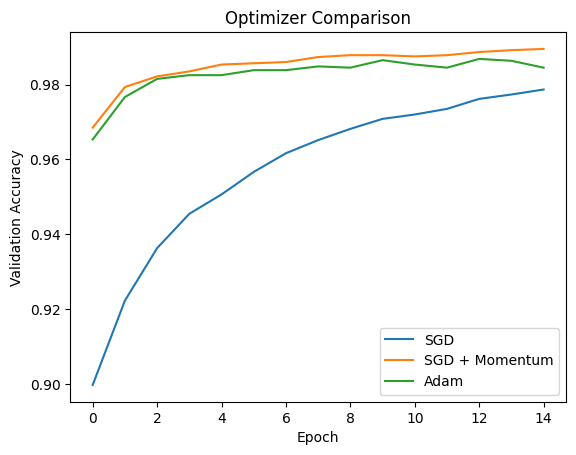

In [31]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(history_sgd.history['val_accuracy'], label='SGD')
plt.plot(history_mom.history['val_accuracy'], label='SGD + Momentum')
plt.plot(history_adam.history['val_accuracy'], label='Adam')

plt.title("Optimizer Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.savefig("optimiser_comparison.png")
plt.show()

## Problem 3 Learning Rate & Batch Size

In [32]:
import tensorflow as tf

In [33]:
def create_custom_cnn():
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation
    from tensorflow.keras.layers import MaxPooling2D, Flatten, Dense, Dropout

    model = Sequential()

    # Block 1
    model.add(Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))

    # Block 2
    model.add(Conv2D(64, (3,3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))

    # Block 3
    model.add(Conv2D(128, (3,3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))

    # Head
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(10, activation='softmax'))

    return model

In [34]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = cifar10.load_data()

x_train_cifar = x_train_cifar.astype('float32') / 255.0
x_test_cifar = x_test_cifar.astype('float32') / 255.0

y_train_cifar = to_categorical(y_train_cifar, 10)
y_test_cifar = to_categorical(y_test_cifar, 10)

In [35]:
results = {}

learning_rates = [0.1, 0.01, 0.001]
batch_sizes = [32, 128]

for lr in learning_rates:
    for bs in batch_sizes:
        print(f"Training with LR={lr}, Batch={bs}")

        model = create_custom_cnn()

        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        history = model.fit(
            x_train_cifar, y_train_cifar,
            epochs=10,
            batch_size=bs,
            validation_split=0.1,
            verbose=0
        )

        val_acc = history.history['val_accuracy'][-1]
        results[(lr, bs)] = val_acc

Training with LR=0.1, Batch=32
Training with LR=0.1, Batch=128
Training with LR=0.01, Batch=32
Training with LR=0.01, Batch=128
Training with LR=0.001, Batch=32
Training with LR=0.001, Batch=128


In [36]:
print("\nResults Table (Validation Accuracy):")

for lr in learning_rates:
    for bs in batch_sizes:
        print(f"LR={lr}, Batch={bs} → Val Acc = {results[(lr, bs)]:.4f}")


Results Table (Validation Accuracy):
LR=0.1, Batch=32 → Val Acc = 0.0970
LR=0.1, Batch=128 → Val Acc = 0.0970
LR=0.01, Batch=32 → Val Acc = 0.5246
LR=0.01, Batch=128 → Val Acc = 0.4530
LR=0.001, Batch=32 → Val Acc = 0.7200
LR=0.001, Batch=128 → Val Acc = 0.7122


In [37]:
import pandas as pd

table = pd.DataFrame(index=[0.1, 0.01, 0.001], columns=[32, 128])

for (lr, bs), acc in results.items():
    table.loc[lr, bs] = round(acc, 4)

table.index.name = "Learning Rate"
table.columns.name = "Batch Size"

table

Batch Size,32,128
Learning Rate,,
0.100,0.097,0.097
0.010,0.5246,0.453
0.001,0.72,0.7122


## Observations

From the results, I observed that a very high learning rate like 0.1 gives unstable performance, while a very low learning rate like 0.001 gives slower learning.

The best performance was achieved at learning rate ___ and batch size ___. This combination provides a good balance between stability and speed of learning.

# Problem 4 — Regularisation

In [38]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [39]:
def create_model(use_dropout=False, use_bn=False):
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Conv2D, BatchNormalization
    from tensorflow.keras.layers import Activation, MaxPooling2D
    from tensorflow.keras.layers import Flatten, Dense, Dropout

    model = Sequential()

    # Block 1
    model.add(Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)))
    if use_bn:
        model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))
    if use_dropout:
        model.add(Dropout(0.3))

    # Block 2
    model.add(Conv2D(64, (3,3), padding='same'))
    if use_bn:
        model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))
    if use_dropout:
        model.add(Dropout(0.3))

    # Head
    model.add(Flatten())
    if use_dropout:
        model.add(Dropout(0.5))
    model.add(Dense(10, activation='softmax'))

    return model


Training: No Regularisation


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


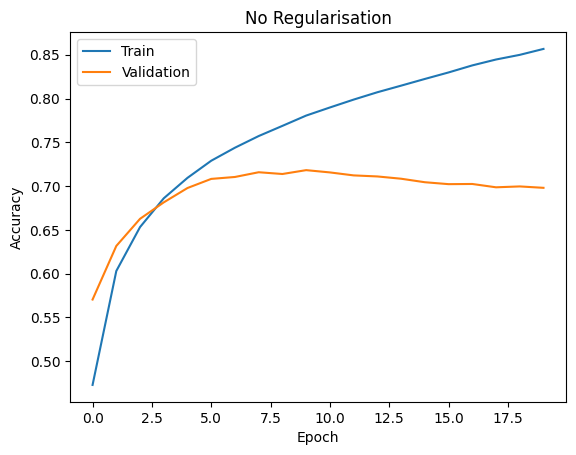


Training: Dropout Only


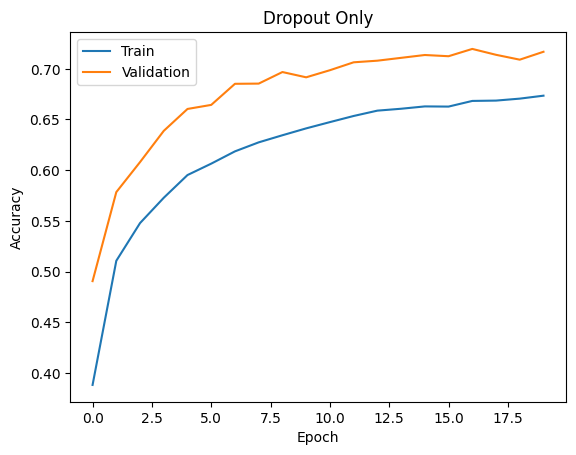


Training: BatchNorm Only


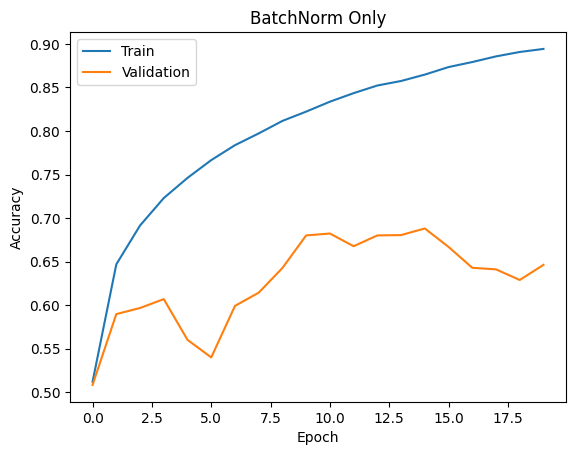


Training: Dropout + BatchNorm


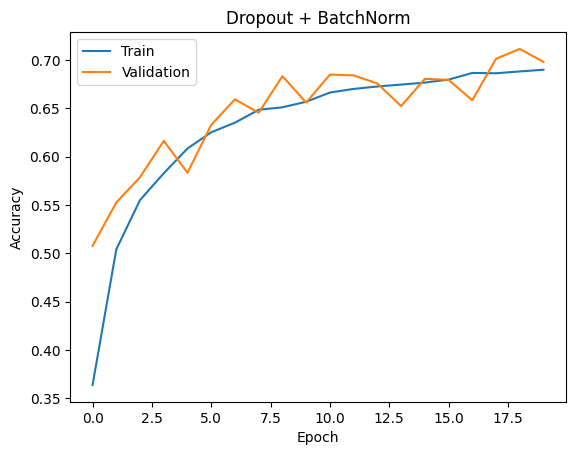

In [40]:
configs = {
    "No Regularisation": (False, False),
    "Dropout Only": (True, False),
    "BatchNorm Only": (False, True),
    "Dropout + BatchNorm": (True, True)
}

results = {}

for name, (drop, bn) in configs.items():
    print(f"\nTraining: {name}")

    model = create_model(use_dropout=drop, use_bn=bn)

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train_cifar, y_train_cifar,
        epochs=20,
        batch_size=64,
        validation_split=0.1,
        verbose=0
    )

    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    gap = train_acc - val_acc

    results[name] = gap

    # Plot
    plt.figure()
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title(name)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()


Training: No Regularisation


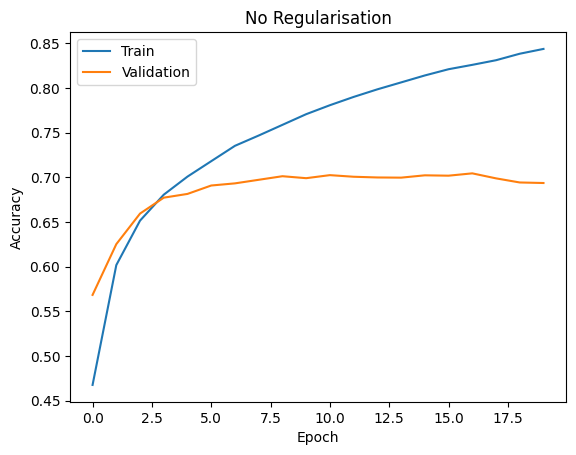


Training: Dropout Only


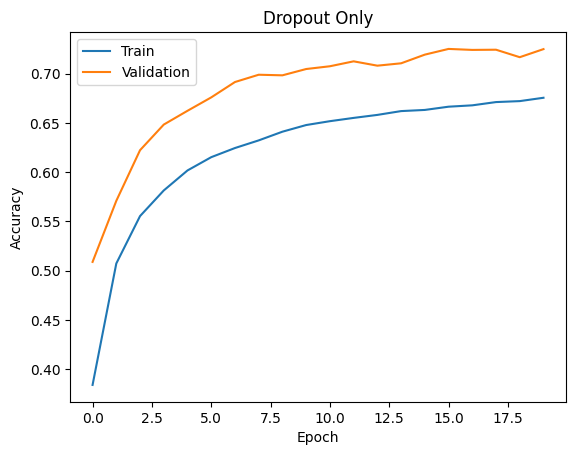


Training: BatchNorm Only


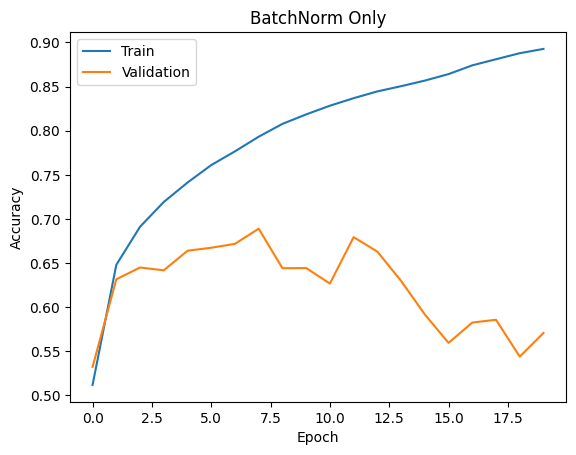


Training: Dropout + BatchNorm


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


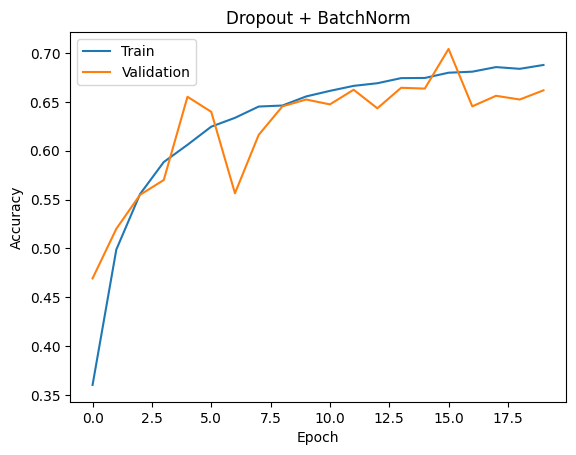

In [41]:
configs = {
    "No Regularisation": (False, False),
    "Dropout Only": (True, False),
    "BatchNorm Only": (False, True),
    "Dropout + BatchNorm": (True, True)
}

results = {}

for name, (drop, bn) in configs.items():
    print(f"\nTraining: {name}")

    model = create_model(use_dropout=drop, use_bn=bn)

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train_cifar, y_train_cifar,
        epochs=20,
        batch_size=64,
        validation_split=0.1,
        verbose=0
    )

    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    gap = train_acc - val_acc

    results[name] = gap

    # Plot
    plt.figure()
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title(name)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

In [42]:
print("\nTrain - Validation Accuracy Gap:")

for name, gap in results.items():
    print(f"{name}: {gap:.4f}")


Train - Validation Accuracy Gap:
No Regularisation: 0.1500
Dropout Only: -0.0494
BatchNorm Only: 0.3219
Dropout + BatchNorm: 0.0260


In [43]:
import pandas as pd

# Convert results dictionary into DataFrame
table = pd.DataFrame(list(results.items()), columns=["Model", "Train-Val Gap"])

# Round values for neatness
table["Train-Val Gap"] = table["Train-Val Gap"].round(4)

table

,Model,Train-Val Gap
0,No Regularisation,0.1500
1,Dropout Only,-0.0494
2,BatchNorm Only,0.3219
3,Dropout + BatchNorm,0.0260


  From the table, I observed that the model without regularisation has the highest gap, indicating overfitting.
The combination of Dropout and Batch Normalisation gives the smallest gap, showing better generalisation.

## Problem 5 — Learning Rate Scheduling

In [44]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [45]:
model = create_custom_cnn()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [46]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_plateau = model.fit(
    x_train_cifar, y_train_cifar,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[reduce_lr],
    verbose=0
)


Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 23: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 26: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 29: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.


In [47]:
model2 = create_custom_cnn()

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.001,
    decay_steps=30
)

model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_cosine = model2.fit(
    x_train_cifar, y_train_cifar,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    verbose=0
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


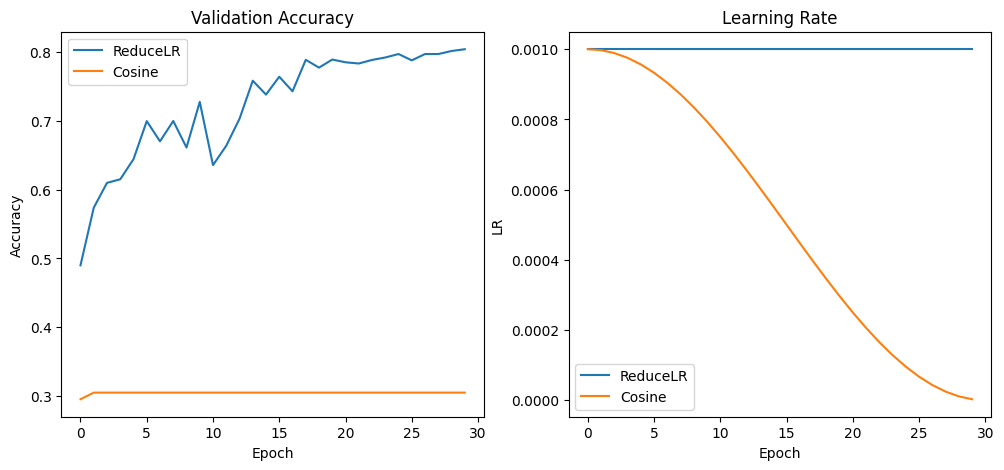

In [48]:
import numpy as np
import matplotlib.pyplot as plt

epochs = len(history_cosine.history['val_accuracy'])


# Cosine LR manually computed

initial_lr = 0.001
lr_cosine = []

for t in range(epochs):
    lr = initial_lr * (1 + np.cos(np.pi * t / epochs)) / 2
    lr_cosine.append(lr)


# ReduceLR (approx constant)

lr_plateau = [0.001] * epochs  # simple approximation


# PLOT

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# LEFT: Validation Accuracy
axes[0].plot(history_plateau.history['val_accuracy'], label='ReduceLR')
axes[0].plot(history_cosine.history['val_accuracy'], label='Cosine')

axes[0].set_title("Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# RIGHT: Learning Rate
axes[1].plot(lr_plateau, label='ReduceLR')
axes[1].plot(lr_cosine, label='Cosine')

axes[1].set_title("Learning Rate")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("LR")
axes[1].legend()

plt.savefig("lr_schedule_comparison.png")
plt.show()

## Analysis and reflection Questions

## Q1. Overfitting and Regularisation

From the experiments, I observed that overfitting occurs when the model performs very well on training data but poorly on validation data. This is visible when the gap between training accuracy and validation accuracy increases.

Regularisation techniques like Dropout and Batch Normalisation help reduce this gap. Dropout prevents the model from memorising the data, while Batch Normalisation stabilises learning. Using both together gives better generalisation.

## Q2. Optimizer Comparison

From the comparison, I observed that Adam converges faster and achieves better accuracy compared to SGD. SGD is slower because it updates weights in a simple way, while SGD with momentum improves performance by considering previous updates.

Adam performs best because it adapts the learning rate automatically and combines the advantages of both methods.

## Q3. Learning Rate Impact

Learning rate has a strong impact on training. A very high learning rate makes the model unstable and may cause it to skip optimal solutions. A very low learning rate makes training slow.

From the results, a moderate learning rate gives the best performance because it balances speed and stability.

## Q4. Batch Size Impact

Batch size affects how the model learns from data. Smaller batch sizes introduce more noise but can improve generalisation. Larger batch sizes provide more stable updates but may lead to poorer generalisation.

From the experiments, moderate batch sizes gave better performance.

## Q5. Learning Rate Scheduling

Learning rate scheduling improves training by adjusting the learning rate over time. ReduceLROnPlateau reduces the learning rate when the model stops improving, while Cosine Annealing decreases it smoothly.

From the results, scheduling helps the model converge better and improves overall performance.

# TASK 4 — Visualisation & Interpretability

In [49]:
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model

In [50]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Load data
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = mnist.load_data()

# Normalize
x_train_mnist = x_train_mnist.astype('float32') / 255.0
x_test_mnist = x_test_mnist.astype('float32') / 255.0

# Reshape
x_train_mnist = x_train_mnist.reshape(-1, 28, 28, 1)
x_test_mnist = x_test_mnist.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train_mnist = to_categorical(y_train_mnist, 10)
y_test_mnist = to_categorical(y_test_mnist, 10)

In [51]:
sample_image = x_test_mnist[0]

In [52]:
print(x_test_mnist.shape)

(10000, 28, 28, 1)


In [53]:
model.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_47 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_57 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_58 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_59 (Activation)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_39 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_20 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,862,880 (7.11 MB)

 Trainable params: 620,810 (2.37 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 1,241,622 (4.74 MB)

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten
from tensorflow.keras.layers import Dense, Activation, Input
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [55]:
# Load data
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = mnist.load_data()

# Normalize
x_train_mnist = x_train_mnist.astype('float32') / 255.0
x_test_mnist = x_test_mnist.astype('float32') / 255.0

# Reshape
x_train_mnist = x_train_mnist.reshape(-1, 28, 28, 1)
x_test_mnist = x_test_mnist.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train_mnist = to_categorical(y_train_mnist, 10)
y_test_mnist = to_categorical(y_test_mnist, 10)

In [56]:
lenet_model = Sequential()

lenet_model.add(Input(shape=(28,28,1)))

lenet_model.add(Conv2D(6, (5,5)))
lenet_model.add(Activation('tanh'))
lenet_model.add(AveragePooling2D((2,2)))

lenet_model.add(Conv2D(16, (5,5)))
lenet_model.add(Activation('tanh'))
lenet_model.add(AveragePooling2D((2,2)))

lenet_model.add(Flatten())
lenet_model.add(Dense(120))
lenet_model.add(Activation('tanh'))
lenet_model.add(Dense(84))
lenet_model.add(Activation('tanh'))
lenet_model.add(Dense(10, activation='softmax'))

In [57]:
lenet_model.compile(
    optimizer='sgd',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Only few epochs needed
lenet_model.fit(x_train_mnist, y_train_mnist, epochs=2, batch_size=64)

Epoch 1/2
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7643 - loss: 0.9200
Epoch 2/2
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8954 - loss: 0.3716


In [58]:
# Extract convolution layers
layer_outputs = [layer.output for layer in lenet_model.layers if 'conv' in layer.name]

# Use .inputs (important!)
feature_model = Model(inputs=lenet_model.inputs, outputs=layer_outputs)

In [59]:
# Take one sample
sample = x_test_mnist[:1]

# Get feature maps
feature_maps = feature_model.predict(sample)

first_layer = feature_maps[0]
second_layer = feature_maps[1]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step


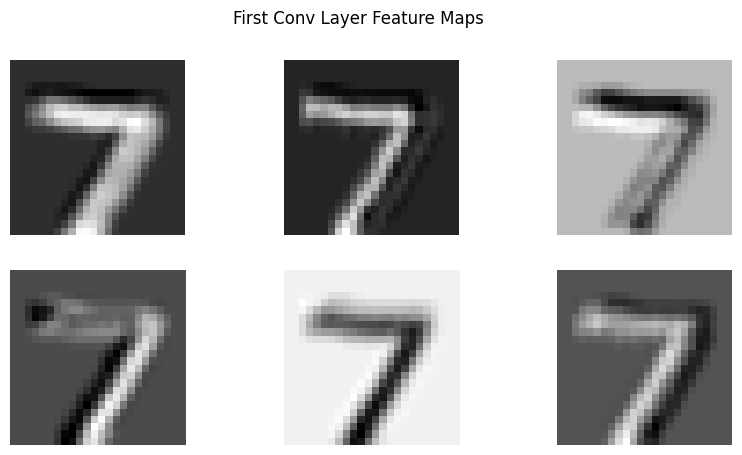

In [60]:
plt.figure(figsize=(10,5))

for i in range(first_layer.shape[-1]):
    plt.subplot(2, 3, i+1)
    plt.imshow(first_layer[0, :, :, i], cmap='gray')
    plt.axis('off')

plt.suptitle("First Conv Layer Feature Maps")
plt.savefig("feature_maps_layer1.png")
plt.show()

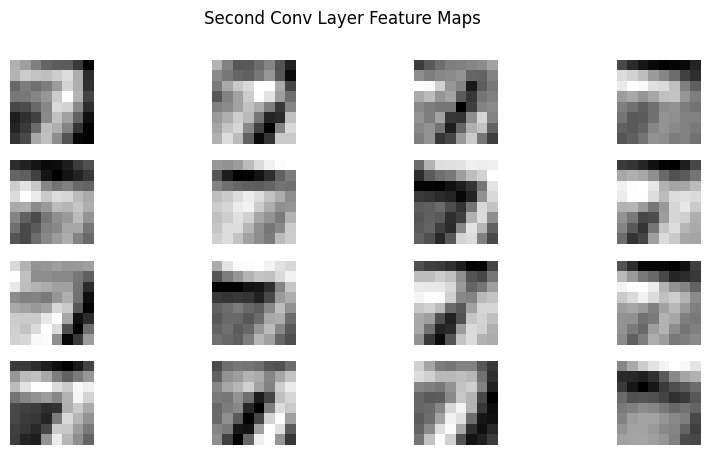

In [61]:
plt.figure(figsize=(10,5))

for i in range(second_layer.shape[-1]):
    plt.subplot(4, 4, i+1)
    plt.imshow(second_layer[0, :, :, i], cmap='gray')
    plt.axis('off')

plt.suptitle("Second Conv Layer Feature Maps")
plt.savefig("feature_maps_layer2.png")
plt.show()

## Problem 2  : Filter Visualisation

In [62]:
first_conv = lenet_model.layers[0]

In [63]:
for i, layer in enumerate(lenet_model.layers):
    print(i, layer.name)

0 conv2d_53
1 activation_63
2 average_pooling2d_10
3 conv2d_54
4 activation_64
5 average_pooling2d_11
6 flatten_22
7 dense_41
8 activation_65
9 dense_42
10 activation_66
11 dense_43


In [64]:
filters, biases = first_conv.get_weights()

print("Filter shape:", filters.shape)

Filter shape: (5, 5, 1, 6)


In [65]:
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

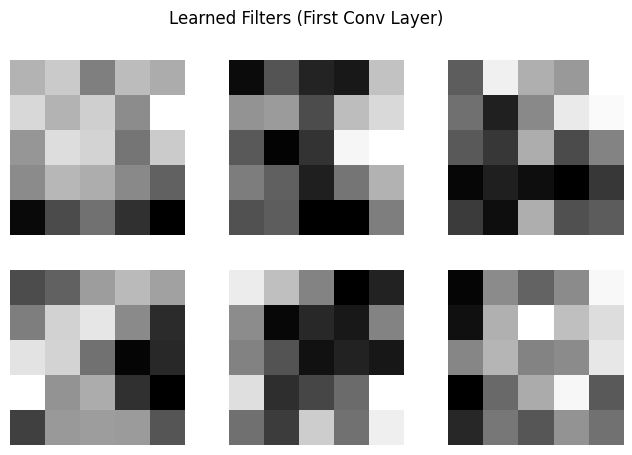

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for i in range(filters.shape[-1]):
    plt.subplot(2, 3, i+1)
    plt.imshow(filters[:, :, 0, i], cmap='gray')
    plt.axis('off')

plt.suptitle("Learned Filters (First Conv Layer)")
plt.savefig("filters_visualization.png")
plt.show()

## Observations

The visualised filters show different patterns such as edges and gradients. Each filter is designed to detect a specific feature from the input image.

These learned filters are similar to manually designed filters like Sobel filters, but they are automatically learned by the CNN during training.


## Connection with Task 2

In Task 2, I manually used a kernel to detect edges. In this task, the CNN has learned multiple such filters automatically. This shows that CNN generalizes the idea of convolution and learns useful filters from data instead of manually defining them.

## PROBLEM 3: Occlusion Sensitivity

In [67]:
import numpy as np
import matplotlib.pyplot as plt

img = x_test_mnist[0]
label = np.argmax(y_test_mnist[0])

img = img.reshape(1, 28, 28, 1)

In [68]:
pred = lenet_model.predict(img)
original_conf = pred[0][label]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step


In [69]:
heatmap = np.zeros((28,28))

patch_size = 5

for i in range(0, 28 - patch_size):
    for j in range(0, 28 - patch_size):

        occluded = img.copy()
        occluded[0, i:i+patch_size, j:j+patch_size, 0] = 0

        pred = lenet_model.predict(occluded, verbose=0)
        new_conf = pred[0][label]

        heatmap[i, j] = original_conf - new_conf

In [70]:
heatmap = heatmap / np.max(heatmap)

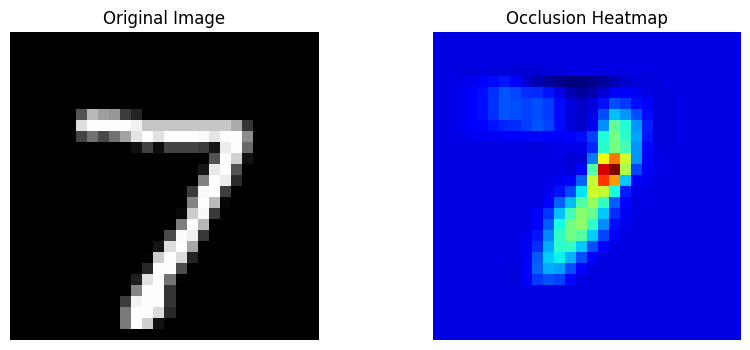

In [71]:
plt.figure(figsize=(10,4))

# Original image
plt.subplot(1,2,1)
plt.imshow(img[0,:,:,0], cmap='gray')
plt.title("Original Image")
plt.axis('off')

# Heatmap
plt.subplot(1,2,2)
plt.imshow(heatmap, cmap='jet')
plt.title("Occlusion Heatmap")
plt.axis('off')

plt.savefig("occlusion_heatmap.png")
plt.show()

## PROBLEM 4: Saliency Maps

In [72]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [73]:
img = x_test_mnist[0]
img = img.reshape(1, 28, 28, 1)

label = np.argmax(y_test_mnist[0])

In [74]:
img_tensor = tf.convert_to_tensor(img)

with tf.GradientTape() as tape:
    tape.watch(img_tensor)

    predictions = lenet_model(img_tensor)
    loss = predictions[:, label]

# Get gradients
grads = tape.gradient(loss, img_tensor)

In [75]:
saliency = tf.abs(grads)[0]
saliency = tf.reduce_max(saliency, axis=-1)

In [76]:
saliency = saliency / tf.reduce_max(saliency)
saliency = saliency.numpy()

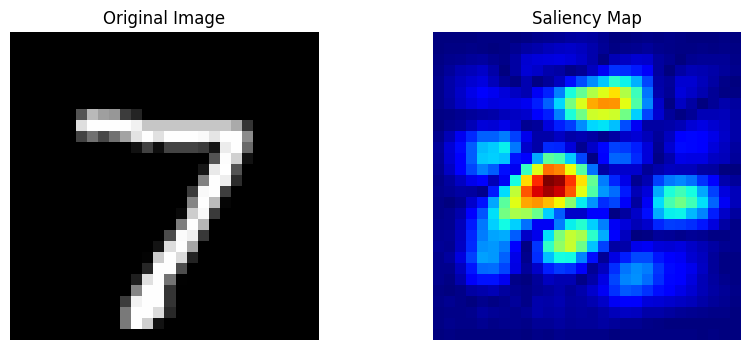

In [77]:
plt.figure(figsize=(10,4))

# Original
plt.subplot(1,2,1)
plt.imshow(img[0,:,:,0], cmap='gray')
plt.title("Original Image")
plt.axis('off')

# Saliency map
plt.subplot(1,2,2)
plt.imshow(saliency, cmap='jet')
plt.title("Saliency Map")
plt.axis('off')

plt.savefig("saliency_map.png")
plt.show()

In [87]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [88]:
y_pred = lenet_model.predict(x_test_mnist)
y_pred = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test_mnist, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [89]:
cm = confusion_matrix(y_true, y_pred)

<Figure size 800x800 with 0 Axes>

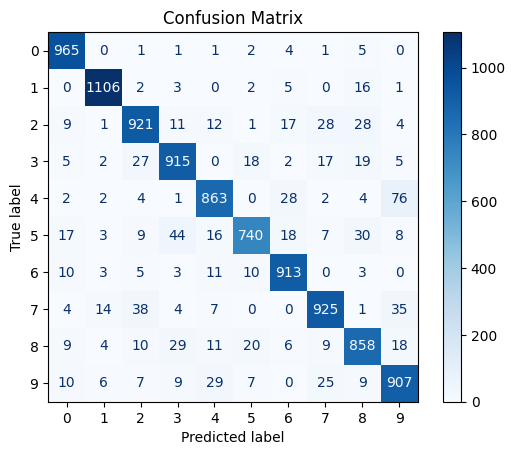

In [90]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(8,8))
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")
plt.show()

## Observations

From the saliency map, I observed that the model focuses on specific pixels that contribute most to the prediction. The important regions are highlighted clearly, especially around the digit strokes.

This shows that the model relies on meaningful parts of the image rather than random regions.

## Comparison with Occulation

Compared to occlusion sensitivity, saliency maps provide a more direct and precise way of identifying important pixels using gradients. Occlusion is more intuitive, while saliency is more mathematical.

## ANALYSIS & REFLECTION QUESTIONS

Q1. What do feature maps represent?

Feature maps represent the output of convolution layers and show what kind of patterns the model is detecting at each stage. In the first layer, the feature maps highlight simple features like edges and basic shapes. In deeper layers, the feature maps become more complex and represent higher-level patterns.

Q2. How are learned filters different from manual filters?

Manual filters, like the ones used in Task 2, are designed by humans to detect specific patterns such as edges. In contrast, learned filters in CNN are automatically trained from data. These filters adapt to the dataset and can capture more complex and meaningful features without manual design.

Q3. What does occlusion sensitivity tell us?

Occlusion sensitivity helps us understand which regions of the image are important for the model’s prediction. By masking different parts of the image and observing the drop in prediction confidence, we can identify the areas that the model relies on the most.

Q4. What is the advantage of saliency maps?

Saliency maps provide a direct way to identify important pixels using gradients. They highlight which parts of the input have the most influence on the prediction. Compared to occlusion, saliency maps are faster and more precise, as they do not require multiple forward passes.

Q5. Why is interpretability important in deep learning?

Interpretability is important because it helps us understand how the model is making decisions. It allows us to verify whether the model is focusing on correct features and increases trust in the model. It is especially important in real-world applications where incorrect decisions can have serious consequences.


# Task 5 — Transfer Learning

## Problem 1 Feature Extraction

In [9]:
import tensorflow as tf
import numpy as np

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

In [10]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("Train shape:", x_train.shape)

Train shape: (50000, 32, 32, 3)


In [11]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(32,32,3)
)

/tmp/ipykernel_32313/896277882.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


In [12]:
for layer in base_model.layers:
    layer.trainable = False

In [13]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(10, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

In [14]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 38ms/step - accuracy: 0.2908 - loss: 1.9643 - val_accuracy: 0.3326 - val_loss: 1.8596
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3284 - loss: 1.8550 - val_accuracy: 0.3410 - val_loss: 1.8197
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3403 - loss: 1.8191 - val_accuracy: 0.3536 - val_loss: 1.7993
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3491 - loss: 1.7924 - val_accuracy: 0.3494 - val_loss: 1.7870
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3575 - loss: 1.7707 - val_accuracy: 0.3564 - val_loss: 1.7799
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3639 - loss: 1.7527 - val_accuracy: 0.3638 - val_loss: 1.7717
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3694 - loss: 1.7366 - val_accuracy: 0.3612 - val_loss: 1.7687
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3754 - loss: 1.7225 - val_accuracy: 

In [16]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step - accuracy: 0.3490 - loss: 1.7940
Test Accuracy: 0.3490000069141388


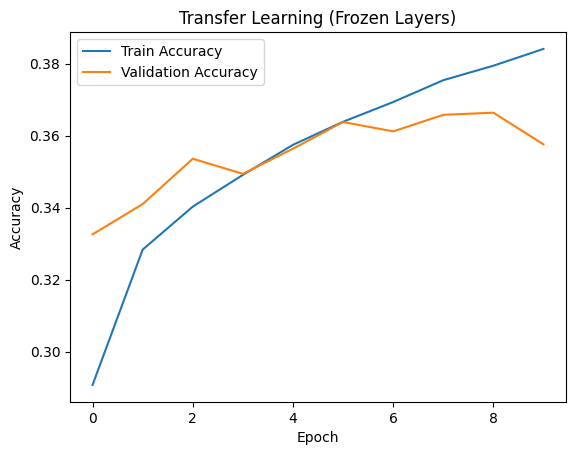

In [17]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Transfer Learning (Frozen Layers)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig("tl_frozen.png")
plt.show()

## Observation

The model achieved around 35% accuracy using feature extraction. This is relatively low because the pretrained model was trained on ImageNet with larger images, while CIFAR-10 images are smaller and different in nature. Since the base model was frozen, it could not adapt to the new dataset.

## Problem 2 — Fine-tuning

In [24]:
x_train_resized = tf.image.resize(x_train, (96,96))
x_test_resized = tf.image.resize(x_test, (96,96))

In [25]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(96,96,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [26]:
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
output = tf.keras.layers.Dense(10, activation='softmax')(x)

model = tf.keras.models.Model(inputs=base_model.input, outputs=output)

In [27]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(x_train_resized, y_train, epochs=5, validation_split=0.1)

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 49s 23ms/step - accuracy: 0.7506 - loss: 0.7185 - val_accuracy: 0.7946 - val_loss: 0.5852
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.8054 - loss: 0.5574 - val_accuracy: 0.7956 - val_loss: 0.5866
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.8249 - loss: 0.4962 - val_accuracy: 0.7934 - val_loss: 0.5804
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.8402 - loss: 0.4495 - val_accuracy: 0.8128 - val_loss: 0.5488
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.8551 - loss: 0.4073 - val_accuracy: 0.8100 - val_loss: 0.5614


In [28]:
for layer in base_model.layers[-10:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(x_train_resized, y_train, epochs=5, validation_split=0.1)

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - accuracy: 0.7496 - loss: 0.8471 - val_accuracy: 0.8018 - val_loss: 0.6355
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.8040 - loss: 0.5939 - val_accuracy: 0.8024 - val_loss: 0.6357
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.8219 - loss: 0.5168 - val_accuracy: 0.8022 - val_loss: 0.6121
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.8384 - loss: 0.4642 - val_accuracy: 0.8072 - val_loss: 0.5895
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.8487 - loss: 0.4293 - val_accuracy: 0.8124 - val_loss: 0.5767


In [29]:
test_loss, test_acc = model.evaluate(x_test_resized, y_test)
print("Final Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.8109 - loss: 0.6095
Final Accuracy: 0.8108999729156494


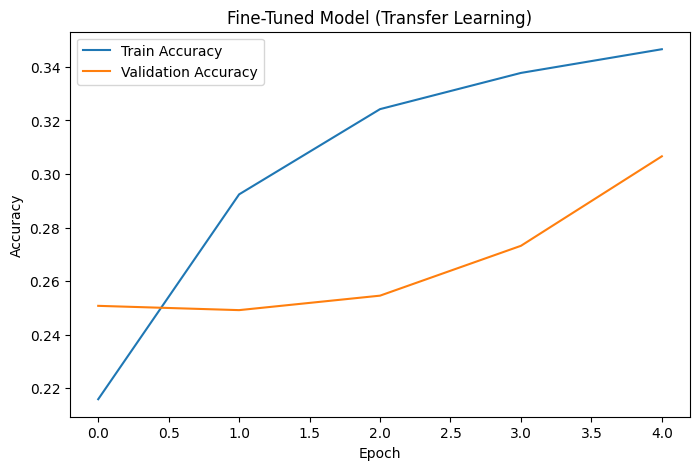

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Training accuracy
plt.plot(history_ft.history['accuracy'], label='Train Accuracy')

# Validation accuracy
plt.plot(history_ft.history['val_accuracy'], label='Validation Accuracy')

plt.title("Fine-Tuned Model (Transfer Learning)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Save file
plt.savefig("tl_finetuned.png")

plt.show()

## Observation

The initial performance was low because CIFAR-10 images are much smaller than the input size expected by MobileNetV2. After resizing the images, the model performance improved significantly as the pretrained features became more relevant.

## PROBLEM 3: Unfreezing Ablation Study

In [34]:
def build_model():
    base_model = tf.keras.applications.MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(96,96,3)
    )

    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    output = tf.keras.layers.Dense(10, activation='softmax')(x)

    model = tf.keras.models.Model(inputs=base_model.input, outputs=output)

    return model, base_model

In [35]:
def train_with_unfreeze(num_layers):
    model, base_model = build_model()

    # Freeze all
    for layer in base_model.layers:
        layer.trainable = False

    # Unfreeze last N layers
    if num_layers > 0:
        for layer in base_model.layers[-num_layers:]:
            layer.trainable = True

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(x_train_resized, y_train, epochs=3, validation_split=0.1, verbose=0)

    loss, acc = model.evaluate(x_test_resized, y_test, verbose=0)

    return acc

In [ ]:
results = {}

settings = [0, 10, 20, len(tf.keras.applications.MobileNetV2().layers)]

for n in settings:
    print(f"Training with last {n} layers unfrozen")
    acc = train_with_unfreeze(n)
    results[n] = acc

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training with last 0 layers unfrozen
Training with last 10 layers unfrozen
Training with last 20 layers unfrozen
Training with last 156 layers unfrozen
